# MM Kinetic Analysis
## Nathan

In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


## MM Functions

In [2]:
class KineticDataException(Exception):
    pass

In [3]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [4]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    """
    Determines best linear fit to initial slope of data, by fitting regressions to 
    all percentiles of the data--greater than some defined minimum--anchored at the origin.
    
    Args:
        time_arr (np.array): array of assay read times
        signal_arr (np.array): array of kinetic signal readouts
        min_included_percent (int) = 5: minimum percent of data to be included 
    
    Returns:
        slope, intercept, score ((float, float, float)): fit parameters of best fit
        
    """
    # Need to triage further for different definitions of minimum
    MIN_INCLUDED_DATA_POINTS = 5
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, 5)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = np.concatenate(perc_times[:i])
        curr_concs = np.concatenate(perc_concs[:i])
        #curr_times = [item for sublist in perc_times[:i] for item in sublist]
        #curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    
    if scores[max_r2_idx] < 0.9:
        return np.array([np.nan]), np.array([np.nan]), np.array([np.nan])
        #return float('nan'), float('nan'), float('nan')
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]


In [5]:
def get_initial_slopes(time_arr: np.array, kinetic_data: np.array, plot: bool = False,
                       substrate_concs: [int] = None, 
                       title: str = None, fig_size: (int, int) = (10,10), triage: bool = False):
    
    if plot and (substrate_concs is None or title is None):
        raise KineticDataException("Plotting initial slopes requires substratce concentration and titles")
    
    slopes = []
    intercepts = []
    scores = []
    
    for data in kinetic_data:
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        slopes.append(slope)
        intercepts.append(intercept)
        scores.append(score)
        
    if plot:
       
        fig = plt.figure(figsize=fig_size) 
        
        for data in kinetic_data:
            plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
       
        x_tiled = np.tile(x,(len(substrate_concs),1)).T
        plt.plot(x_tiled,
                 x_tiled * np.array(slopes).T + np.array(intercepts).T,
                 linewidth=3, label=[f"{sub_conc:.2f} µM" for sub_conc in substrate_concs])
        plt.title(title)
        plt.xlabel("Time (seconds)")
        plt.ylabel("µM")
        plt.legend() 
    
        if triage:

            fig, axs = plt.subplots(math.ceil(len(sub_concs) / 2), 2, figsize=(15,15))

            for ax, data, slope, intercept, sub_conc in zip(axs.flat, kinetic_data, slopes, intercepts, substrate_concs):
                ax.scatter(time_arr, data)
                ax.set_title(f"{sub_conc:.2f} µM")
                ax.plot(x, x * slope + intercept)
           
    return np.concatenate(slopes)

In [6]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [7]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.nanmean([rep_1_slopes, rep_2_slopes], axis=0)[..., np.newaxis]
   
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.nanstd([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 1000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

# Data Cleaning and Prep

In [51]:
bgadk_df = pd.read_csv("/Users/duncanmuir/Downloads/07_21_2022_bryan_adk_nadph.csv", header=0)

In [47]:
bgadk_df.head()

,1000 uM,1000 uM.1,500 uM,500 uM.1,250 uM,250 uM.1,125 uM,125 uM.1,62.5 uM,62.5 uM.1,31.25 uM,31.25 uM.1,15.625 uM,15.625 uM.1,7.8125 uM,7.8125 uM.1
0,12204,12048,10418,10346,9645,9642,9380,9252,9314,8852,8652,8478,8748,8571,8824,8893
1,12587,12306,10524,10503,9929,9821,9506,9271,9317,9021,8790,8710,8785,8625,8939,8954
2,12729,12412,10693,10568,10101,9995,9600,9447,9426,9147,8712,8651,8825,8679,8867,8966
3,12890,12497,10786,10749,10099,10099,9687,9506,9529,9050,8798,8630,8756,8676,8986,8918
4,12880,12525,10972,10834,10245,10252,9795,9569,9509,9188,8829,8737,8753,8686,8879,8945


In [15]:
time_arr = np.array(bgadk_df["Time [s]"])

In [16]:
time_arr.shape

(523,)

The shape of the time array indicates our expected number of signal readings ^ so the second dimension of all our subsequent arrays should match this.

In [50]:
no_enz_df = pd.read_csv("/Users/duncanmuir/Downloads/07_21_2022_bryan_adk_nadph_control.csv", header=0)

In [46]:
no_enz_df.head()

,1000 uM,1000 uM.1,500 uM,500 uM.1,250 uM,250 uM.1,125 uM,125 uM.1,62.5 uM,62.5 uM.1,31.25 uM,31.25 uM.1,15.625 uM,15.625 uM.1,7.8125 uM,7.8125 uM.1
0,10544,11880,8861,10106,8116,9235,61879,8941,7922,8801,7856,8477,8058,8534,8331,8590
1,10661,11923,8834,10072,8193,9382,63566,8954,7915,8847,7887,8510,7991,8481,8334,8513
2,10508,11883,8810,9998,8114,9200,62162,8845,7802,8690,7842,8397,7955,8492,8291,8559
3,10563,11888,8844,10025,8142,9329,62320,8851,7826,8815,7848,8448,7960,8448,8360,8491
4,10511,11802,8780,9940,8108,9258,61865,8844,7807,8750,7772,8398,7964,8412,8230,8508


# Computing Background Rates

In [45]:
RFU_TO_NADPH_CONVERSION_FACTOR = 207

In this case, the wells are indicated by columns, and I am looking for wells [J1:J16]

In [52]:
no_enz_df = no_enz_df.iloc[:,1:]

In [53]:
no_enz_arr = np.array(no_enz_df) / RFU_TO_NADPH_CONVERSION_FACTOR
no_enz_arr.shape

(523, 16)

We need to transpose our array as our desired time count dimension is currently the first dimension.

In [54]:
no_enz_arr = no_enz_arr.transpose()
no_enz_arr.shape

(16, 523)

I did my replicates next to each other along the row, so J1==J2, J3==J4 etc.,
so now I need to separate by replicates.

In [55]:
no_enz_rep_1_arr = no_enz_arr[0::2]
no_enz_rep_2_arr = no_enz_arr[1::2]

In [29]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

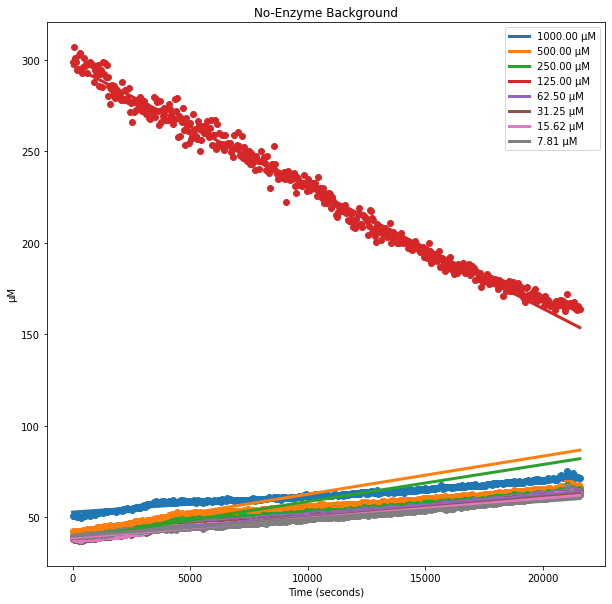

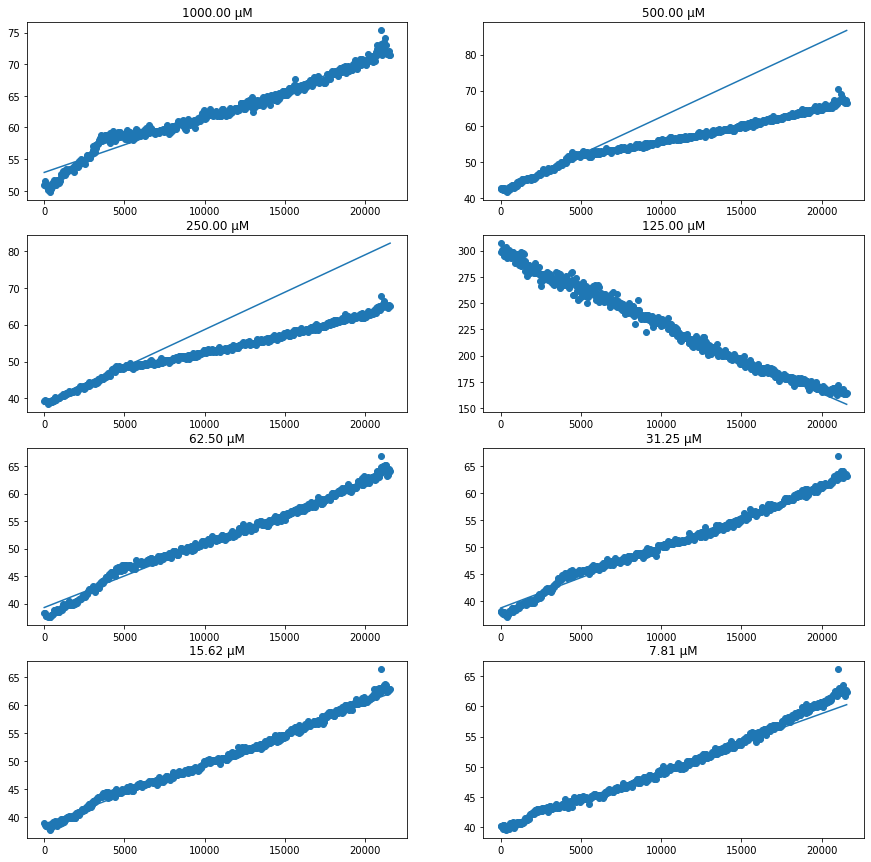

In [56]:
no_enz_rep_1_slopes = get_initial_slopes(time_arr, no_enz_rep_1_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background", triage=True)

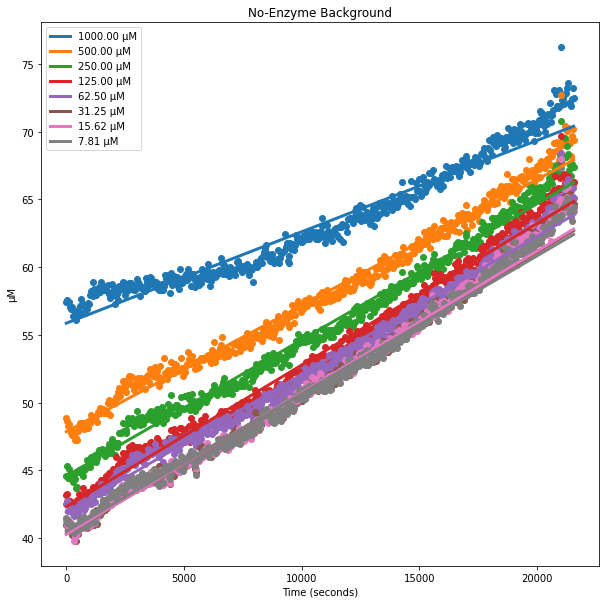

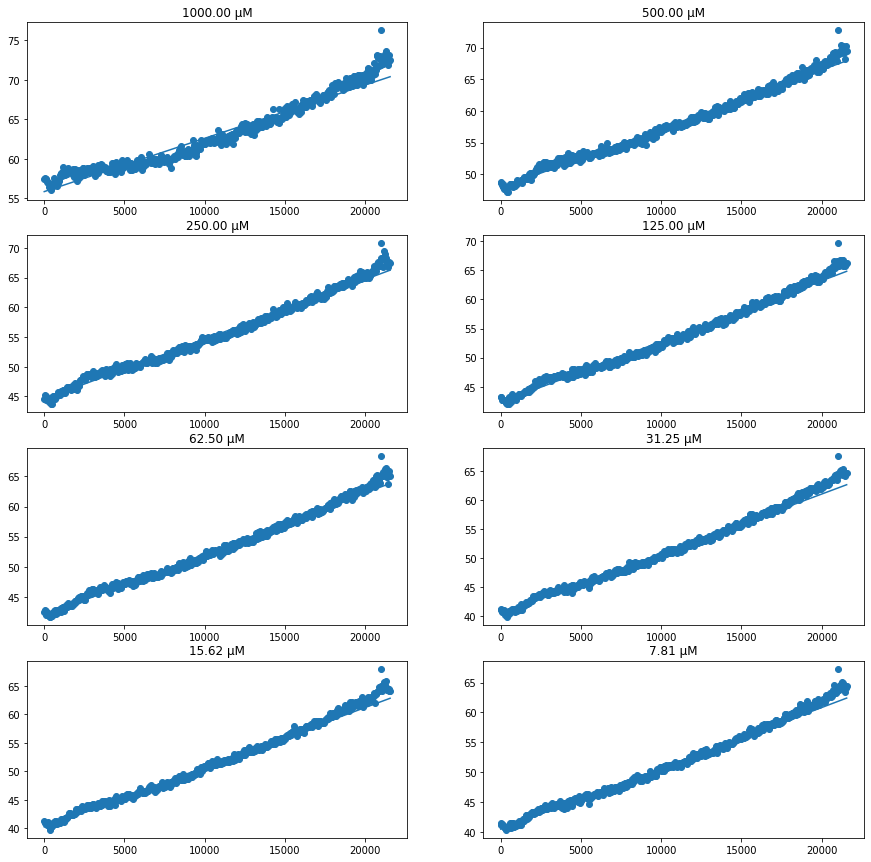

In [57]:
no_enz_rep_2_slopes = get_initial_slopes(time_arr, no_enz_rep_2_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background", triage=True)

# gsADK I111L Data

In [58]:
bgadk_df = bgadk_df.iloc[:,1:]
bgadk_arr = np.array(bgadk_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [59]:
bgadk_arr_rep1 = bgadk_arr[0::2]
bgadk_arr_rep2 = bgadk_arr[1::2]

In [60]:
gs_i111l_conc = .618 * 2e-4

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

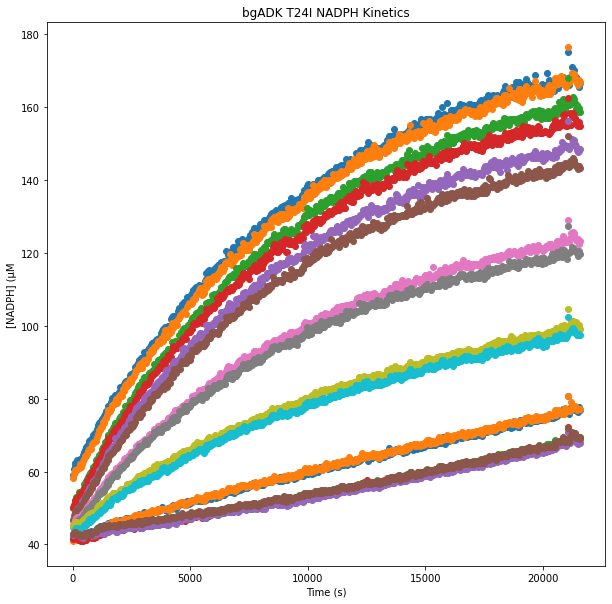

In [61]:
fig = plt.figure(figsize=(10,10))

for data in bgadk_arr:
    plt.scatter(time_arr, data)
plt.title("bgADK T24I NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

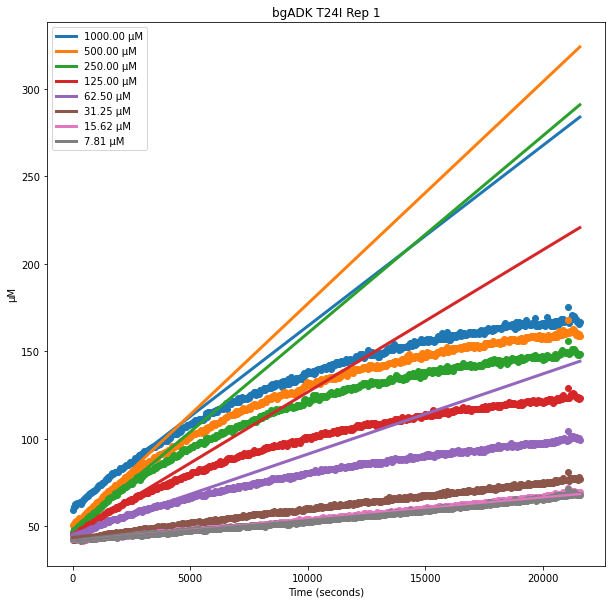

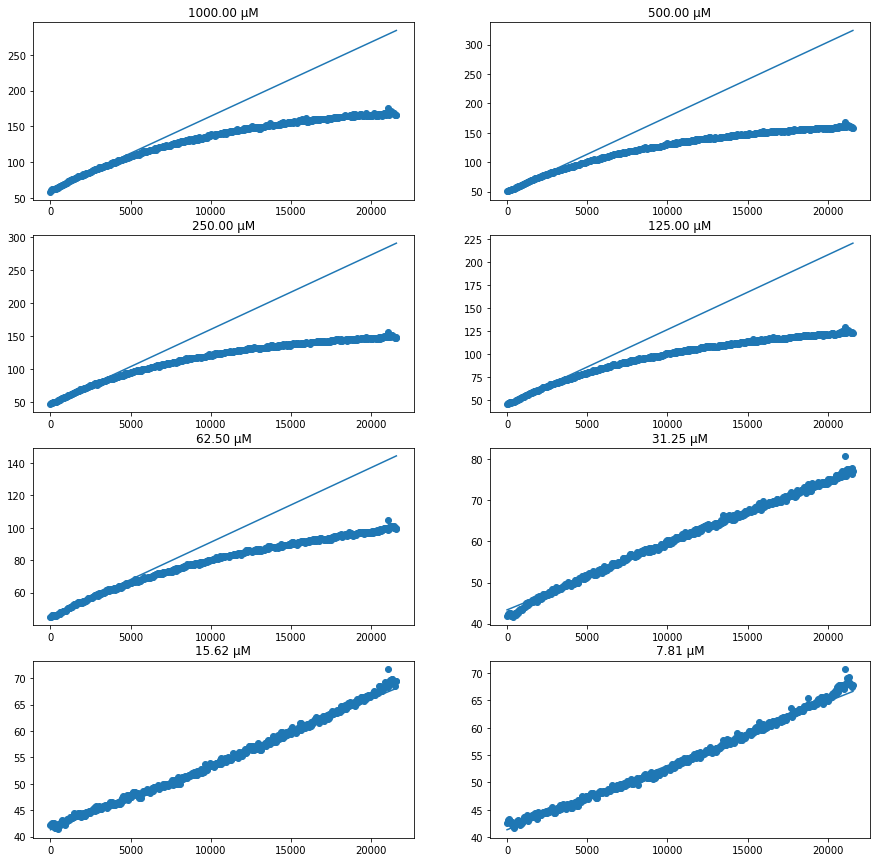

In [62]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
bgADK_r1_slopes = get_initial_slopes(time_arr, bgadk_arr_rep1, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bgADK T24I Rep 1", triage=True)

In [63]:
gsADK_i111l_r1_slopes

NameError: name 'gsADK_i111l_r1_slopes' is not defined

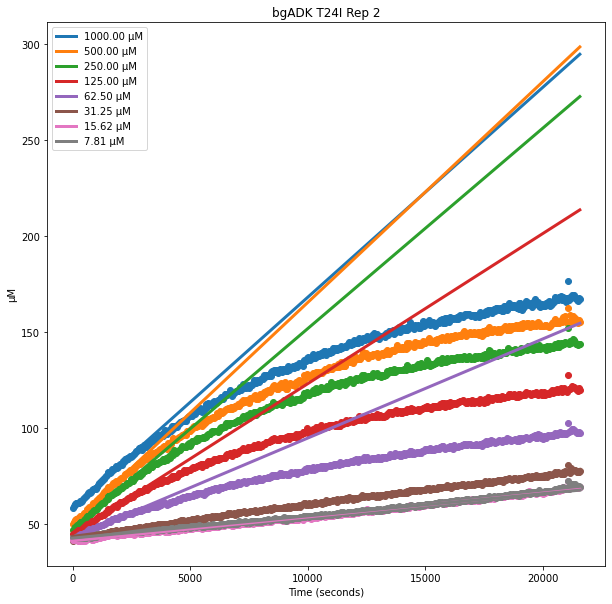

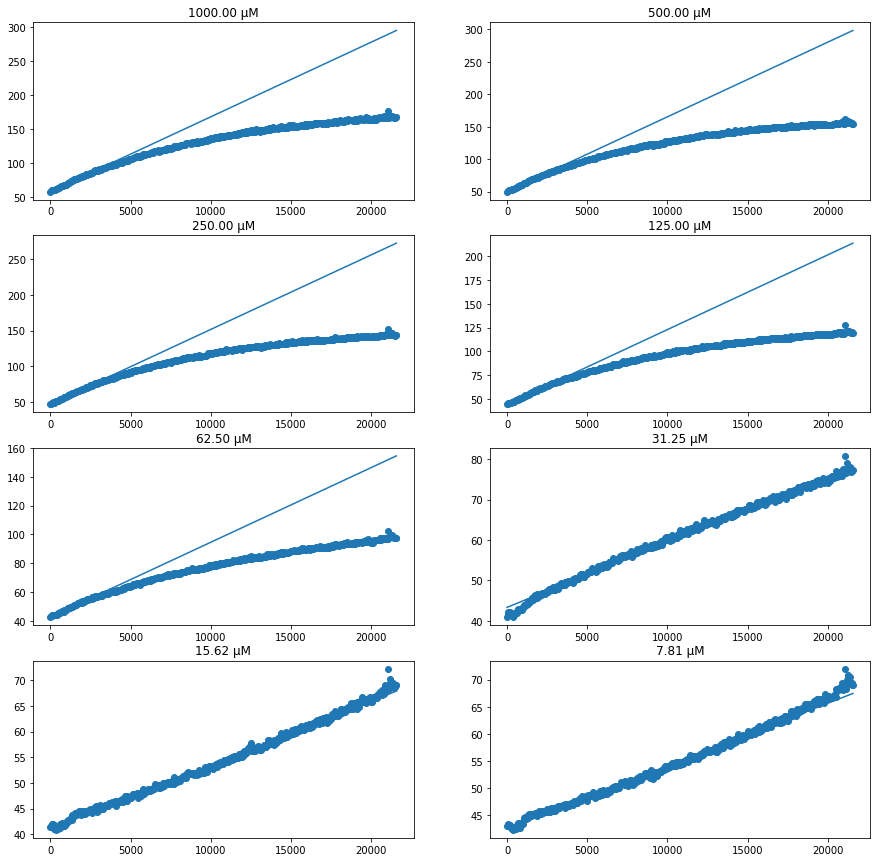

In [64]:
bgADK_r2_slopes = get_initial_slopes(time_arr, bgadk_arr_rep2, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bgADK T24I Rep 2", triage=True)

In [65]:
bg_adk_conc = 125 * 1e-6

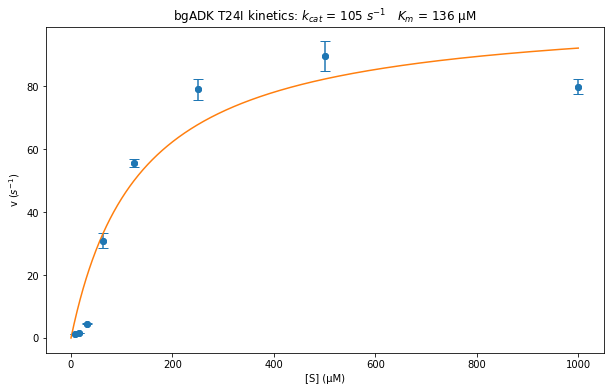

In [66]:
fit_and_plot_micheaelis_menten(np.array(bgADK_r1_slopes), np.array(bgADK_r2_slopes), sub_concs, 
                               bg_adk_conc, "bgADK T24I", np.mean([no_enz_rep_2_slopes, no_enz_rep_2_slopes], axis=0)[..., np.newaxis])

Cut off initial rxn data when flat/artifcact